In [1]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty")  # <<< updated path here to refer to the implementation
import Utils
import Inject_Missing_Values
import imputers
import Gain
import MIWAE


In [2]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from Inject_Missing_Values import *
from imputers import *
from imputers_updated import *
from Utils import *
from Gain import *
from MIWAE import *
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

In [4]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)
import torch.nn as nn

Loading the data

In [5]:
data = fetch_openml(name="diabetes", version=1, as_frame=True)
X_full = data.data.copy()

In [6]:
print(X_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB
None


In [7]:
print(X_full)

     preg  plas  pres  skin  insu  mass   pedi  age
0       6   148    72    35     0  33.6  0.627   50
1       1    85    66    29     0  26.6  0.351   31
2       8   183    64     0     0  23.3  0.672   32
3       1    89    66    23    94  28.1  0.167   21
4       0   137    40    35   168  43.1  2.288   33
..    ...   ...   ...   ...   ...   ...    ...  ...
763    10   101    76    48   180  32.9  0.171   63
764     2   122    70    27     0  36.8  0.340   27
765     5   121    72    23   112  26.2  0.245   30
766     1   126    60     0     0  30.1  0.349   47
767     1    93    70    31     0  30.4  0.315   23

[768 rows x 8 columns]


In [8]:
#scaler = MinMaxScaler() #data [0,1]
#X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

scaler = StandardScaler()
X_full =  pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

In [9]:
print(X_full)

         preg      plas      pres      skin      insu      mass      pedi  \
0    0.639947  0.848324  0.149641  0.907270 -0.692891  0.204013  0.468492   
1   -0.844885 -1.123396 -0.160546  0.530902 -0.692891 -0.684422 -0.365061   
2    1.233880  1.943724 -0.263941 -1.288212 -0.692891 -1.103255  0.604397   
3   -0.844885 -0.998208 -0.160546  0.154533  0.123302 -0.494043 -0.920763   
4   -1.141852  0.504055 -1.504687  0.907270  0.765836  1.409746  5.484909   
..        ...       ...       ...       ...       ...       ...       ...   
763  1.827813 -0.622642  0.356432  1.722735  0.870031  0.115169 -0.908682   
764 -0.547919  0.034598  0.046245  0.405445 -0.692891  0.610154 -0.398282   
765  0.342981  0.003301  0.149641  0.154533  0.279594 -0.735190 -0.685193   
766 -0.844885  0.159787 -0.470732 -1.288212 -0.692891 -0.240205 -0.371101   
767 -0.844885 -0.873019  0.046245  0.656358 -0.692891 -0.202129 -0.473785   

          age  
0    1.425995  
1   -0.190672  
2   -0.105584  
3   -1.0415

Storing the clean data as Ground Truth

In [10]:
GroundTruth = X_full.copy()
X = X_full.copy()

In [11]:
GroundTruth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    float64
 1   plas    768 non-null    float64
 2   pres    768 non-null    float64
 3   skin    768 non-null    float64
 4   insu    768 non-null    float64
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    float64
dtypes: float64(8)
memory usage: 48.1 KB


Converting GroundTruth to tensor

In [12]:
GroundTruth_tensor = torch.tensor(GroundTruth.values, dtype=torch.double)

In [13]:
GroundTruth.nunique()

preg     17
plas    136
pres     47
skin     51
insu    186
mass    248
pedi    517
age      52
dtype: int64

Dependecies for MAR & MNAR

In [14]:
mean_age = GroundTruth["age"].mean()
mean_preg = GroundTruth["preg"].mean()
mean_plas = GroundTruth["plas"].mean()
median_pres = GroundTruth["pres"].median()
median_skin = GroundTruth["skin"].median()
mean_insu = GroundTruth["insu"].mean()
mean_mass = GroundTruth["mass"].mean()
median_pedi = GroundTruth["pedi"].median()

dependencies_mar = {
    "preg": {
        "influencers": ["plas"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["plas"] >= mean_plas else 0.1
    },
    "plas": {
        "influencers": ["mass"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["mass"] <= mean_mass else 0.1
    },
    "pres": {
        "influencers": ["age"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] >= mean_age else 0.1
    },
    "skin": {
        "influencers": ["pres"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["pres"] <= median_pres else 0.1
    },
    "insu": {
        "influencers": ["preg"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["preg"] >= mean_preg else 0.1
    },
    "mass": {
        "influencers": ["pedi"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["pedi"] >= median_pedi else 0.1
    },
    "pedi": {
        "influencers": ["skin"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["skin"] <= median_skin else 0.1
    },
    "age": {
        "influencers": ["insu"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["insu"] >= mean_insu else 0.1
    }
}


In [15]:
mean_preg = GroundTruth["preg"].mean()
mean_plas = GroundTruth["plas"].mean()
median_pres = GroundTruth["pres"].median()
median_skin = GroundTruth["skin"].median()
mean_insu = GroundTruth["insu"].mean()
mean_mass = GroundTruth["mass"].mean()
median_pedi = GroundTruth["pedi"].median()
mean_age = GroundTruth["age"].mean()


dependencies_mnar = {
    "preg": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["preg"] >= mean_preg else 0.1
    },
    "plas": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["plas"] < mean_plas else 0.1
    },
    "pres": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["pres"] <= median_pres else 0.1
    },
    "skin": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["skin"] >= median_skin else 0.1
    },
    "insu": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["insu"] > mean_insu else 0.1
    },
    "mass": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["mass"] <= mean_mass else 0.1
    },
    "pedi": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["pedi"] >= median_pedi else 0.1
    },
    "age": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["age"] > mean_age else 0.1
    }
}


In [16]:
def ensemble_imputation(imputers, X_missing):
    """
    imputers: dict of {name: imputer_object} - each with a fit_transform method
    X_missing: input data with missing values
    
    Returns:
      ensemble_imputed: average of all imputers' single imputations
    """
    imputed_list = []
    for name, imputer in imputers.items():
        imputed = imputer.fit_transform(X_missing)  # run once per imputer
        imputed_list.append(imputed)
    
    all_imputations = np.stack(imputed_list)  # shape: (n_imputers, n_samples, n_features)
    ensemble_imputed = all_imputations.mean(axis=0)  # average over imputers
    
    return ensemble_imputed


## MCAR

Multiple Runs

In [17]:

missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing


rng = np.random.default_rng(42)


# Create nested results dictionary
results_mcar = []


for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    runs = 4
    #missing mask
    missing_mask = miss_mcar.isna()

    #OT
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 100, batchsize=128)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy()
        imputed_runs_OT.append(X_imputed_OT)

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)

    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "MAE": OT_mae
        })

    #Mice
   
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=100, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mcar)
        #X_imputed_mice = X_imputed_tensor_mice.numpy()
        imputed_runs_mice.append(X_imputed_mice)

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
    #print(imputed_std_mice)

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "MAE": mice_mae
        })

    
    #VAE
    print("VAEAC")
    imputed_runs_vae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mcar.copy()
        vae_mask = ~np.isnan(X_missing) 
      

        # 2. Instantiate your VAE
        input_dim = X_missing.shape[1]
       # True where data is observed
        vae_model= VAEAC(input_dim=input_dim, hidden_dim=64, latent_dim=16)

        # 3. Train and impute
        recon, mu, std = vae_model.train_vae(X_missing, mask = vae_mask.astype(float), epochs=100, batch_size=32)
        imputed_runs_vae.append(recon)

    imputed_stack_vae = np.stack(imputed_runs_vae, axis=0)
    imputed_mean_vae = np.nanmean(imputed_stack_vae, axis=0)
    imputed_std_vae = np.nanstd(imputed_stack_vae, axis=0)
   

    mae_vae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_vae[missing_mask.values]
    )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_vae[missing_mask.values].flatten(),
                   imputed_std_vae[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "VAEAC",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "MAE": mae_vae
        })






    print("MIWAE")

    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        #X_missing = miss_mcar.copy()
        #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=10, epochs=100)
        X_imputed_miwae = imputer.fit_transform(miss_mcar)

        imputed_runs_miwae.append(X_imputed_miwae)

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    #print(imputed_std_vae)

    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mcar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "MAE": mae_miwae
        })


    #GAIN
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=100, batch_size=128)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
        #print(imputed_std_vae)

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s,
                "MAE": mae_gain
            })



    



df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mcar_results_multiple_runs.csv", index=False)

10
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
20
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
40
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
50
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Ru

Multiple runs comparision

In [18]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = np.arange(10, 90, 10)
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mcar = Inject_Missing_Values()
    miss_mcar, _ = generator_mcar.MCAR(X, missing_rate=missing_rate)
    missing_mask = miss_mcar.isna()
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    X_missing = miss_mcar.copy()

    algorithms = ["OT-Impute", "MICE", "VAEAC", "MIWAE", "GAIN"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=100, batchsize=128)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
                
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=100, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "VAEAC":
                vae_mask = ~np.isnan(X_missing)
                vae_model = VAEAC(input_dim=input_dim, hidden_dim=64, latent_dim=16)
                recon, mu, std = vae_model.train_vae(X_missing, mask = vae_mask.astype(float), epochs=100, batch_size=32)
                imputed = recon
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=10, epochs=100)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=100, batch_size=128)
                imputed = imputer.fit_transform(X_missing_tensor)
                
                       
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Compute MAE for run and progressive mean ===
            mae_run = mean_absolute_error(
                GroundTruth.values[missing_mask.values],
                imputed[missing_mask.values]
            )
            mae_prog_mean = mean_absolute_error(
                GroundTruth.values[missing_mask.values],
                imputed_mean[missing_mask.values]
            )

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MAE_Run": mae_run,
                    "MeanSoFar": m,
                    "StdSoFar": s,
                    "MAE_ProgressiveMean": mae_prog_mean
                })

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mcar_results_progressive.csv", index=False)





=== Missing rate: 10% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running VAEAC for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

=== Missing rate: 20% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running VAEAC for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
R

Multiple Sample Run

In [19]:

missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [20,30,40,50,60,70,80,90,100]

# Create nested results dictionary
results_mcar = []


for missing_rate in missing_rates:
    print(missing_rate)
    for sample in samples:
        #genarating missing vlaues
        print(sample)
        generator_mcar = Inject_Missing_Values()
        miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        #missing mask
        missing_mask = miss_mcar.isna()

        #VAE
        print("VAE")
        
        X_missing = miss_mcar.copy()
        vae_mask = ~np.isnan(X_missing) 
        #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

            # 2. Instantiate your VAE
        input_dim = X.shape[1]
        # True where data is observed
        vaeac = VAEAC(input_dim=input_dim, hidden_dim=128, latent_dim=32)
        vaeac.train_vae(X_missing, mask = vae_mask.astype(float), epochs=100, batch_size=32)

        # 4. Get imputations + uncertainty
        mean_vae, std_vae = vaeac.vae_with_std(X_missing,mask = vae_mask,
            num_samples=sample
        )

        #print(imputed_std_vae)

        mae_vae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_vae[missing_mask.values]
        )
        for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    mean_vae[missing_mask.values].flatten(),
                    std_vae[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm": "VAEAC",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s,
                "MAE": mae_vae,
                "Sample": sample

            })
        
        print("MIWAE")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
        miwae = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=50, epochs=50)
        mean_miwae, std_miwae= miwae.fit_transform_std(X_missing, return_std=True, inference_K=sample)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries



        mae_miwae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwae[missing_mask.values]
        )
        for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwae[missing_mask.values].flatten(),
                        std_miwae[missing_mask.values].flatten()):
            results_mcar.append({
                "Algorithm": "MIWAE",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s,
                "MAE": mae_miwae,
                "Sample": sample
            })

        #GAIN
        print("GAIN")
        imputer_gain = GAINImputer()
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
        mae_gain = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gain[missing_mask.values]
            )
        for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gain[missing_mask.values].flatten(),
                        std_gain[missing_mask.values].flatten()):
                results_mcar.append({
                    "Algorithm": "GAIN",
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "MAE": mae_gain,
                    "Sample": sample
                })


df_results = pd.DataFrame(results_mcar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mcar_results_sample_runs.csv", index=False)

10
20
VAE
MIWAE
GAIN
30
VAE
MIWAE
GAIN
40
VAE
MIWAE
GAIN
50
VAE
MIWAE
GAIN
60
VAE
MIWAE
GAIN
70
VAE
MIWAE
GAIN
80
VAE
MIWAE
GAIN
90
VAE
MIWAE
GAIN
100
VAE
MIWAE
GAIN
20
20
VAE
MIWAE
GAIN
30
VAE
MIWAE
GAIN
40
VAE
MIWAE
GAIN
50
VAE
MIWAE
GAIN
60
VAE
MIWAE
GAIN
70
VAE
MIWAE
GAIN
80
VAE
MIWAE
GAIN
90
VAE
MIWAE
GAIN
100
VAE
MIWAE
GAIN
30
20
VAE
MIWAE
GAIN
30
VAE
MIWAE
GAIN
40
VAE
MIWAE
GAIN
50
VAE
MIWAE
GAIN
60
VAE
MIWAE
GAIN
70
VAE
MIWAE
GAIN
80
VAE
MIWAE
GAIN
90
VAE
MIWAE
GAIN
100
VAE
MIWAE
GAIN
40
20
VAE
MIWAE
GAIN
30
VAE
MIWAE
GAIN
40
VAE
MIWAE
GAIN
50
VAE
MIWAE
GAIN
60
VAE
MIWAE
GAIN
70
VAE
MIWAE
GAIN
80
VAE
MIWAE
GAIN
90
VAE
MIWAE
GAIN
100
VAE
MIWAE
GAIN
50
20
VAE
MIWAE
GAIN
30
VAE
MIWAE
GAIN
40
VAE
MIWAE
GAIN
50
VAE
MIWAE
GAIN
60
VAE
MIWAE
GAIN
70
VAE
MIWAE
GAIN
80
VAE
MIWAE
GAIN
90
VAE
MIWAE
GAIN
100
VAE
MIWAE
GAIN
60
20
VAE
MIWAE
GAIN
30
VAE
MIWAE
GAIN
40
VAE
MIWAE
GAIN
50
VAE
MIWAE
GAIN
60
VAE
MIWAE
GAIN
70
VAE
MIWAE
GAIN
80
VAE
MIWAE
GAIN
90
VAE
MIWAE
GAIN
100
VAE
MIWAE
GAIN
70
2

## MAR

Multiple Runs

In [20]:

missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing


rng = np.random.default_rng(42)


# Create nested results dictionary
results_mar = []


for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    runs = 4
    #missing mask
    missing_mask = miss_mar.isna()

    #OT
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 100, batchsize=128)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy()
        imputed_runs_OT.append(X_imputed_OT)

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)

    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "MAE": OT_mae
        })

    #Mice
   
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=100, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mar)
        #X_imputed_mice = X_imputed_tensor_mice.numpy()
        imputed_runs_mice.append(X_imputed_mice)

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
   

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "MAE": mice_mae
        })

    
    #VAE
    print("VAEAC")
    imputed_runs_vae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mar.copy()
        vae_mask = ~np.isnan(X_missing) 
      

        # 2. Instantiate your VAE
        input_dim = X_missing.shape[1]
       # True where data is observed
        vae_model= VAEAC(input_dim=input_dim, hidden_dim=64, latent_dim=16)

        # 3. Train and impute
        recon, mu, std = vae_model.train_vae(X_missing, mask = vae_mask.astype(float), epochs=100, batch_size=32)
        imputed_runs_vae.append(recon)

    imputed_stack_vae = np.stack(imputed_runs_vae, axis=0)
    imputed_mean_vae = np.nanmean(imputed_stack_vae, axis=0)
    imputed_std_vae = np.nanstd(imputed_stack_vae, axis=0)
   

    mae_vae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_vae[missing_mask.values]
    )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_vae[missing_mask.values].flatten(),
                   imputed_std_vae[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "VAEAC",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "MAE": mae_vae
        })






    print("MIWAE")

    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        #X_missing = miss_mcar.copy()
        #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=10, epochs=100)
        X_imputed_miwae = imputer.fit_transform(miss_mar)

        imputed_runs_miwae.append(X_imputed_miwae)

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    #print(imputed_std_vae)

    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "MAE": mae_miwae
        })


    #GAIN
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=100, batch_size=128)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
    

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s,
                "MAE": mae_gain
            })



    



df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mar_results_multiple_runs.csv", index=False)

10
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
20
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
40
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
50
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Ru

Multiple runs comparision

In [21]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = np.arange(10, 90, 10)
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mar = Inject_Missing_Values()
    miss_mar, _ = generator_mar.MAR(X, missing_rate=missing_rate,dependencies=dependencies_mar)
    missing_mask = miss_mar.isna()
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    X_missing = miss_mar.copy()

    algorithms = ["OT-Impute", "MICE", "VAEAC", "MIWAE", "GAIN"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=100, batchsize=128)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
               
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=100, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "VAEAC":
                vae_mask = ~np.isnan(X_missing)
                vae_model = VAEAC(input_dim=input_dim, hidden_dim=64, latent_dim=16)
                recon, mu, std = vae_model.train_vae(X_missing, mask = vae_mask.astype(float), epochs=100, batch_size=32)
                imputed = recon
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=10, epochs=100)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=100, batch_size=128)
                imputed = imputer.fit_transform(X_missing_tensor)
                
               
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Compute MAE for run and progressive mean ===
            mae_run = mean_absolute_error(
                GroundTruth.values[missing_mask.values],
                imputed[missing_mask.values]
            )
            mae_prog_mean = mean_absolute_error(
                GroundTruth.values[missing_mask.values],
                imputed_mean[missing_mask.values]
            )

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MAE_Run": mae_run,
                    "MeanSoFar": m,
                    "StdSoFar": s,
                    "MAE_ProgressiveMean": mae_prog_mean
                })

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mar_results_progressive.csv", index=False)





=== Missing rate: 10% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running VAEAC for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

=== Missing rate: 20% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running VAEAC for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
R

Multiple Sample Run

In [22]:

missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [20,30,40,50,60,70,80,90,100]

# Create nested results dictionary
results_mar = []


for missing_rate in missing_rates:
    print(missing_rate)
    for sample in samples:
        #genarating missing vlaues
        print(sample)
        generator_mar = Inject_Missing_Values()
        miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)
        X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
        #missing mask
        missing_mask = miss_mar.isna()

        #VAEAC
        print("VAEAC")
        
        X_missing = miss_mar.copy()
        vae_mask = ~np.isnan(X_missing) 
        #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

            # 2. Instantiate your VAE
        input_dim = X.shape[1]
        # True where data is observed
        vaeac = VAEAC(input_dim=input_dim, hidden_dim=128, latent_dim=32)
        vaeac.train_vae(X_missing, mask = vae_mask.astype(float), epochs=100, batch_size=32)

        # 4. Get imputations + uncertainty
        mean_vae, std_vae = vaeac.vae_with_std(X_missing,mask = vae_mask,
            num_samples=sample
        )

        #print(imputed_std_vae)

        mae_vae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_vae[missing_mask.values]
        )
        for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    mean_vae[missing_mask.values].flatten(),
                    std_vae[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "VAEAC",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s,
                "MAE": mae_vae,
                "Sample": sample

            })
        
        print("MIWAE")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
        miwae = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=50, epochs=50)
        mean_miwae, std_miwae= miwae.fit_transform_std(X_missing, return_std=True, inference_K=sample)

    # X_imputed: full dataset with missing replaced by mean imputation
    # aleatoric_std: same shape, np.nan for observed entries, numeric std for missing entries



        mae_miwae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwae[missing_mask.values]
        )
        for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwae[missing_mask.values].flatten(),
                        std_miwae[missing_mask.values].flatten()):
            results_mar.append({
                "Algorithm": "MIWAE",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s,
                "MAE": mae_miwae,
                "Sample": sample
            })

        #GAIN
        print("GAIN")
        imputer_gain = GAINImputer()
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
        mae_gain = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gain[missing_mask.values]
            )
        for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gain[missing_mask.values].flatten(),
                        std_gain[missing_mask.values].flatten()):
                results_mar.append({
                    "Algorithm": "GAIN",
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "MAE": mae_gain,
                    "Sample": sample
                })




    



df_results = pd.DataFrame(results_mar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mar_results_sample_runs.csv", index=False)

10
20
VAEAC
MIWAE


GAIN
30
VAEAC
MIWAE
GAIN
40
VAEAC
MIWAE
GAIN
50
VAEAC
MIWAE
GAIN
60
VAEAC
MIWAE
GAIN
70
VAEAC
MIWAE
GAIN
80
VAEAC
MIWAE
GAIN
90
VAEAC
MIWAE
GAIN
100
VAEAC
MIWAE
GAIN
20
20
VAEAC
MIWAE
GAIN
30
VAEAC
MIWAE
GAIN
40
VAEAC
MIWAE
GAIN
50
VAEAC
MIWAE
GAIN
60
VAEAC
MIWAE
GAIN
70
VAEAC
MIWAE
GAIN
80
VAEAC
MIWAE
GAIN
90
VAEAC
MIWAE
GAIN
100
VAEAC
MIWAE
GAIN
30
20
VAEAC
MIWAE
GAIN
30
VAEAC
MIWAE
GAIN
40
VAEAC
MIWAE
GAIN
50
VAEAC
MIWAE
GAIN
60
VAEAC
MIWAE
GAIN
70
VAEAC
MIWAE
GAIN
80
VAEAC
MIWAE
GAIN
90
VAEAC
MIWAE
GAIN
100
VAEAC
MIWAE
GAIN
40
20
VAEAC
MIWAE
GAIN
30
VAEAC
MIWAE
GAIN
40
VAEAC
MIWAE
GAIN
50
VAEAC
MIWAE
GAIN
60
VAEAC
MIWAE
GAIN
70
VAEAC
MIWAE
GAIN
80
VAEAC
MIWAE
GAIN
90
VAEAC
MIWAE
GAIN
100
VAEAC
MIWAE
GAIN
50
20
VAEAC
MIWAE
GAIN
30
VAEAC
MIWAE
GAIN
40
VAEAC
MIWAE
GAIN
50
VAEAC
MIWAE
GAIN
60
VAEAC
MIWAE
GAIN
70
VAEAC
MIWAE
GAIN
80
VAEAC
MIWAE
GAIN
90
VAEAC
MIWAE
GAIN
100
VAEAC
MIWAE
GAIN
60
20
VAEAC
MIWAE
GAIN
30
VAEAC
MIWAE
GAIN
40
VAEAC
MIWAE
GAIN
50
VAEAC
MIWAE
GAIN
60
VAEAC
MIWAE


## MNAR

Multiple Runs

In [23]:

missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing


rng = np.random.default_rng(42)


# Create nested results dictionary
results_mnar = []


for missing_rate in missing_rates:

    #genarating missing vlaues
    print(missing_rate)
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    runs = 4
    #missing mask
    missing_mask = miss_mnar.isna()

    #OT
    imputed_runs_OT = []
    print("OT-Impute")
    for i in range(runs):
        print(f"Run {i+1}...")
        ot_imputer = OTimputer(niter = 100, batchsize=128)
        X_imputed_tensor_OT = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed_OT = X_imputed_tensor_OT.detach().numpy()
        imputed_runs_OT.append(X_imputed_OT)

    imputed_stack_OT = np.stack(imputed_runs_OT, axis=0)
    imputed_mean_OT = np.nanmean(imputed_stack_OT, axis=0)
    imputed_std_OT = np.nanstd(imputed_stack_OT, axis=0)

    OT_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_OT[missing_mask.values]
    )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_OT[missing_mask.values].flatten(),
                   imputed_std_OT[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "OT-Impute",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "MAE": OT_mae
        })

    #Mice
   
    imputed_runs_mice = []
    print("MICE")
    for i in range(runs):
        print(f"Run {i+1}...")
        mice_imputer = IterativeImputer(max_iter=100, sample_posterior=True, random_state=None)
        X_imputed_mice = mice_imputer.fit_transform(miss_mnar)
        imputed_runs_mice.append(X_imputed_mice)

    imputed_stack_mice = np.stack(imputed_runs_mice, axis=0)
    imputed_mean_mice = np.nanmean(imputed_stack_mice, axis=0)
    imputed_std_mice = np.nanstd(imputed_stack_mice, axis=0)
  

    mice_mae = mean_absolute_error(
       GroundTruth.values[missing_mask.values],
        imputed_mean_mice[missing_mask.values]
    )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_mice[missing_mask.values].flatten(),
                   imputed_std_mice[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MICE",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "MAE": mice_mae
        })

    
    #VAE
    print("VAEAC")
    imputed_runs_vae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        X_missing = miss_mcar.copy()
        vae_mask = ~np.isnan(X_missing) 
      

        # 2. Instantiate your VAE
        input_dim = X_missing.shape[1]
       # True where data is observed
        vae_model= VAEAC(input_dim=input_dim, hidden_dim=64, latent_dim=16)

        # 3. Train and impute
        recon, mu, std = vae_model.train_vae(X_missing, mask = vae_mask.astype(float), epochs=100, batch_size=32)
        imputed_runs_vae.append(recon)

    imputed_stack_vae = np.stack(imputed_runs_vae, axis=0)
    imputed_mean_vae = np.nanmean(imputed_stack_vae, axis=0)
    imputed_std_vae = np.nanstd(imputed_stack_vae, axis=0)
   

    mae_vae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_vae[missing_mask.values]
    )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                   imputed_mean_vae[missing_mask.values].flatten(),
                   imputed_std_vae[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "VAEAC",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "MAE": mae_vae
        })






    print("MIWAE")

    imputed_runs_miwae = []

    for i in range(runs):
        print(f"Run {i+1}...")
        #X_missing = miss_mcar.copy()
        #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

        # 2. Instantiate your VAE
        imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=10, epochs=100)
        X_imputed_miwae = imputer.fit_transform(miss_mnar)

        imputed_runs_miwae.append(X_imputed_miwae)

    imputed_stack_miwae = np.stack(imputed_runs_miwae, axis=0)
    imputed_mean_miwae = np.nanmean(imputed_stack_miwae, axis=0)
    imputed_std_miwae = np.nanstd(imputed_stack_miwae, axis=0)
    

    mae_miwae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_miwae[missing_mask.values]
    )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_miwae[missing_mask.values].flatten(),
                    imputed_std_miwae[missing_mask.values].flatten()):
        results_mnar.append({
            "Algorithm": "MIWAE",
            "MissingRate": missing_rate,
            "TrueValue": t,
            "ImputedMean": m,
            "ImputedStd": s,
            "MAE": mae_miwae
        })


    #GAIN
    print("GAIN")
    imputed_runs_gain = []

    for i in range(runs):
        
        print(f"Run {i+1}...")
        imputer_gain = GAINImputer(epochs=100, batch_size=128)
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        imputed_runs_gain.append(X_imputed_gain)

    imputed_stack_gain = np.stack(imputed_runs_gain, axis=0)
    imputed_mean_gain = np.nanmean(imputed_stack_gain, axis=0)
    imputed_std_gain = np.nanstd(imputed_stack_gain, axis=0)
        #print(imputed_std_vae)

    mae_gain = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        imputed_mean_gain[missing_mask.values]
        )
    for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    imputed_mean_gain[missing_mask.values].flatten(),
                    imputed_std_gain[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm": "GAIN",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s,
                "MAE": mae_gain
            })



    



df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mnar_results_multiple_runs.csv", index=False)

10
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
20
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
30
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
40
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Run 1...
Run 2...
Run 3...
Run 4...
GAIN
Run 1...
Run 2...
Run 3...
Run 4...
50
OT-Impute
Run 1...
Run 2...
Run 3...
Run 4...
MICE
Run 1...
Run 2...
Run 3...
Run 4...
VAEAC
Run 1...
Run 2...
Run 3...
Run 4...
MIWAE
Ru

Multiple runs comparision

In [24]:
import numpy as np
import pandas as pd
import torch
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Assuming already defined:
# Inject_Missing_Values, OTimputer, VAE, MIWAEImputer, GAINImputer, ensemble_imputation
# GroundTruth, X

missing_rates = np.arange(10, 90, 10)
runs = 10  # Total runs

results_all = []  # Store all results in one list

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {missing_rate}% ===")
    
    # Generate missing data once
    generator_mnar = Inject_Missing_Values()
    miss_mnar, _ = generator_mnar.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
    missing_mask = miss_mnar.isna()
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    X_missing = miss_mnar.copy()

    algorithms = ["OT-Impute", "MICE", "VAEAC", "MIWAE", "GAIN"]

    for algo in algorithms:
        print(f"\nRunning {algo} for {runs} runs...")

        imputed_stack = []  # Store imputations so far

        for run in range(1, runs + 1):
            print(f"Run {run}...")

            # === Imputation ===
            if algo == "OT-Impute":
                imputer = OTimputer(niter=100, batchsize=128)
                imputed = imputer.fit_transform(X_missing_tensor).detach().numpy()
               
              

            elif algo == "MICE":
                imputer = IterativeImputer(max_iter=100, sample_posterior=True, random_state=None)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "VAEAC":
                vae_mask = ~np.isnan(X_missing)
                vae_model = VAEAC(input_dim=input_dim, hidden_dim=64, latent_dim=16)
                recon, mu, std = vae_model.train_vae(X_missing, mask = vae_mask.astype(float), epochs=100, batch_size=32)
                imputed = recon
             

            elif algo == "MIWAE":
                imputer = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                            hidden_dims=[128, 64], K=10, epochs=100)
                imputed = imputer.fit_transform(X_missing)
               

            elif algo == "GAIN":
                imputer = GAINImputer(epochs=100, batch_size=128)
                imputed = imputer.fit_transform(X_missing_tensor)
                
            
            imputed_stack.append(imputed)

            # === Compute progressive mean/std ===
            imputed_array = np.stack(imputed_stack, axis=0)
            imputed_mean = np.nanmean(imputed_array, axis=0)
            imputed_std = np.nanstd(imputed_array, axis=0)

            # === Compute MAE for run and progressive mean ===
            mae_run = mean_absolute_error(
                GroundTruth.values[missing_mask.values],
                imputed[missing_mask.values]
            )
            mae_prog_mean = mean_absolute_error(
                GroundTruth.values[missing_mask.values],
                imputed_mean[missing_mask.values]
            )

            # === Save each missing cell’s results ===
            for t, v, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                                  imputed[missing_mask.values].flatten(),
                                  imputed_mean[missing_mask.values].flatten(),
                                  imputed_std[missing_mask.values].flatten()):
                results_all.append({
                    "Algorithm": algo,
                    "MissingRate": missing_rate,
                    "Run": run,
                    "TrueValue": t,
                    "ImputedValue": v,
                    "MAE_Run": mae_run,
                    "MeanSoFar": m,
                    "StdSoFar": s,
                    "MAE_ProgressiveMean": mae_prog_mean
                })

# Save everything
df_results = pd.DataFrame(results_all)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mnar_results_progressive.csv", index=False)





=== Missing rate: 10% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running VAEAC for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MIWAE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running GAIN for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

=== Missing rate: 20% ===

Running OT-Impute for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running MICE for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
Run 8...
Run 9...
Run 10...

Running VAEAC for 10 runs...
Run 1...
Run 2...
Run 3...
Run 4...
Run 5...
Run 6...
Run 7...
R

Multiple Sample Run

In [25]:

missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing


rng = np.random.default_rng(42)
samples = [20,30,40,50,60,70,80,90,100]

# Create nested results dictionary
results_mnar = []


for missing_rate in missing_rates:
    print(missing_rate)
    for sample in samples:
        #genarating missing vlaues
        print(sample)
        generator_mnar = Inject_Missing_Values()
        miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)
        X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
        #missing mask
        missing_mask = miss_mnar.isna()

        #VAEAC
        print("VAEAC")
        
        X_missing = miss_mnar.copy()
        vae_mask = ~np.isnan(X_missing) 
        #X_missing[np.isnan(X_missing)] = 0  # fill missing with 0 for input

            # 2. Instantiate your VAE
        input_dim = X.shape[1]
        # True where data is observed
        vaeac = VAEAC(input_dim=input_dim, hidden_dim=128, latent_dim=32)
        vaeac.train_vae(X_missing, mask = vae_mask.astype(float), epochs=100, batch_size=32)

        # 4. Get imputations + uncertainty
        mean_vae, std_vae = vaeac.vae_with_std(X_missing,mask = vae_mask,
            num_samples=sample
        )

        #print(imputed_std_vae)

        mae_vae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_vae[missing_mask.values]
        )
        for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                    mean_vae[missing_mask.values].flatten(),
                    std_vae[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm": "VAEAC",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s,
                "MAE": mae_vae,
                "Sample": sample

            })
        
        print("MIWAE")
    
        # X_missing: pandas DataFrame or numpy array with np.nan for missing
        miwae = MIWAEImputer(input_dim=X_missing.shape[1], latent_dim=10,
                        hidden_dims=[128, 64], K=50, epochs=50)
        mean_miwae, std_miwae= miwae.fit_transform_std(X_missing, return_std=True, inference_K=sample)

        mae_miwae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_miwae[missing_mask.values]
        )
        for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_miwae[missing_mask.values].flatten(),
                        std_miwae[missing_mask.values].flatten()):
            results_mnar.append({
                "Algorithm": "MIWAE",
                "MissingRate": missing_rate,
                "TrueValue": t,
                "ImputedMean": m,
                "ImputedStd": s,
                "MAE": mae_miwae,
                "Sample": sample
            })

        #GAIN
        print("GAIN")
        imputer_gain = GAINImputer()
        X_imputed_gain = imputer_gain.fit_transform(X_missing_tensor)
        mean_gain, std_gain = imputer_gain.sample(num_samples=sample)
        mae_gain = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            mean_gain[missing_mask.values]
            )
        for t, m, s in zip(GroundTruth.values[missing_mask.values].flatten(),
                        mean_gain[missing_mask.values].flatten(),
                        std_gain[missing_mask.values].flatten()):
                results_mnar.append({
                    "Algorithm": "GAIN",
                    "MissingRate": missing_rate,
                    "TrueValue": t,
                    "ImputedMean": m,
                    "ImputedStd": s,
                    "MAE": mae_gain,
                    "Sample": sample
                })




    



df_results = pd.DataFrame(results_mnar)
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mnar_results_sample_runs.csv", index=False)

10
20
VAEAC
MIWAE
GAIN
30
VAEAC
MIWAE
GAIN
40
VAEAC
MIWAE
GAIN
50
VAEAC
MIWAE
GAIN
60
VAEAC
MIWAE
GAIN
70
VAEAC
MIWAE
GAIN
80
VAEAC
MIWAE
GAIN
90
VAEAC
MIWAE
GAIN
100
VAEAC
MIWAE
GAIN
20
20
VAEAC
MIWAE
GAIN
30
VAEAC
MIWAE
GAIN
40
VAEAC
MIWAE
GAIN
50
VAEAC
MIWAE
GAIN
60
VAEAC
MIWAE
GAIN
70
VAEAC
MIWAE
GAIN
80
VAEAC
MIWAE
GAIN
90
VAEAC
MIWAE
GAIN
100
VAEAC
MIWAE
GAIN
30
20
VAEAC
MIWAE
GAIN
30
VAEAC
MIWAE
GAIN
40
VAEAC
MIWAE
GAIN
50
VAEAC
MIWAE
GAIN
60
VAEAC
MIWAE
GAIN
70
VAEAC
MIWAE
GAIN
80
VAEAC
MIWAE
GAIN
90
VAEAC
MIWAE
GAIN
100
VAEAC
MIWAE
GAIN
40
20
VAEAC
MIWAE
GAIN
30
VAEAC
MIWAE
GAIN
40
VAEAC
MIWAE
GAIN
50
VAEAC
MIWAE
GAIN
60
VAEAC
MIWAE
GAIN
70
VAEAC
MIWAE
GAIN
80
VAEAC
MIWAE
GAIN
90
VAEAC
MIWAE
GAIN
100
VAEAC
MIWAE
GAIN
50
20
VAEAC
MIWAE
GAIN
30
VAEAC
MIWAE
GAIN
40
VAEAC
MIWAE
GAIN
50
VAEAC
MIWAE
GAIN
60
VAEAC
MIWAE
GAIN
70
VAEAC
MIWAE
GAIN
80
VAEAC
MIWAE
GAIN
90
VAEAC
MIWAE
GAIN
100
VAEAC
MIWAE
GAIN
60
20
VAEAC
MIWAE
GAIN
30
VAEAC
MIWAE
GAIN
40
VAEAC
MIWAE
GAIN
50
VAEAC
MIWAE
GA

## Visualizations

## MCAR

20% MCAR calibration curves

C:\Users\zhossai3\AppData\Local\Temp\ipykernel_552\1021824220.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({


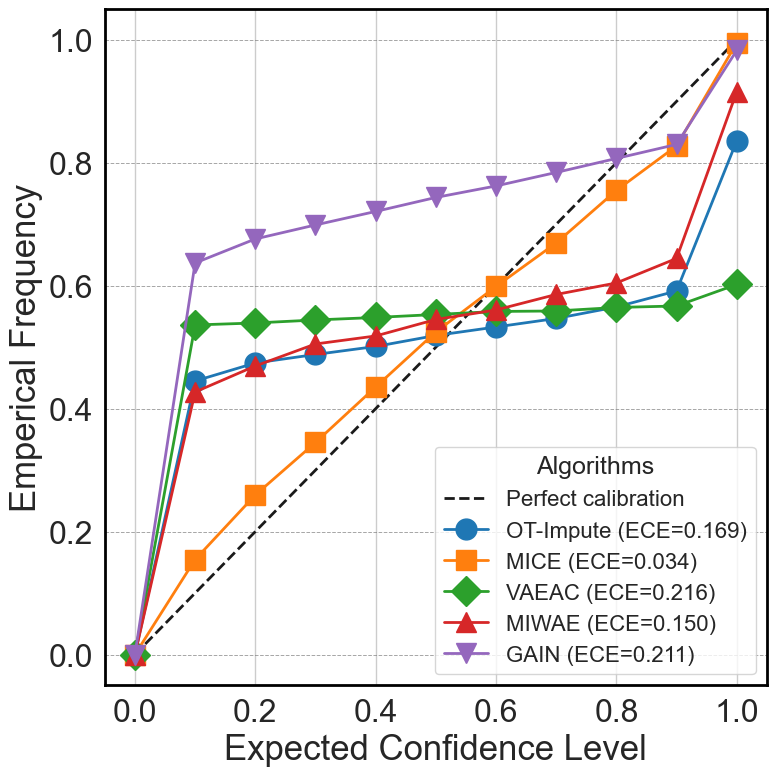

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mcar_results_multiple_runs.csv"
)

target_missing_rate = 20  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

# Rename algorithms for consistency
df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble":"Ensemble"
})

algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})"
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Algorithms", fontsize=16, title_fontsize=18)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MCAR20_Calibration_multiple runs.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


Multiple runs ECE VS Missing Rate

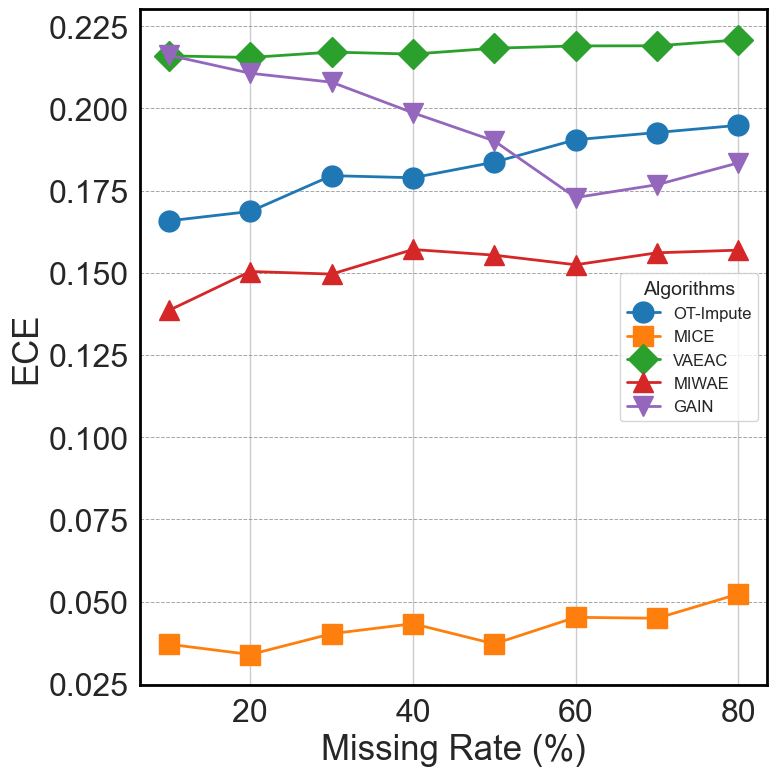

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mcar_results_multiple_runs.csv"
)

# Rename algorithms for consistency
df_results['Algorithm'] = df_results['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble": "Ensemble"
})

algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(title="Algorithms", fontsize=12, title_fontsize=14)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MCAR_ECE_AllAlgorithms.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


20% MCAR Sample runs

C:\Users\zhossai3\AppData\Local\Temp\ipykernel_552\971542819.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({


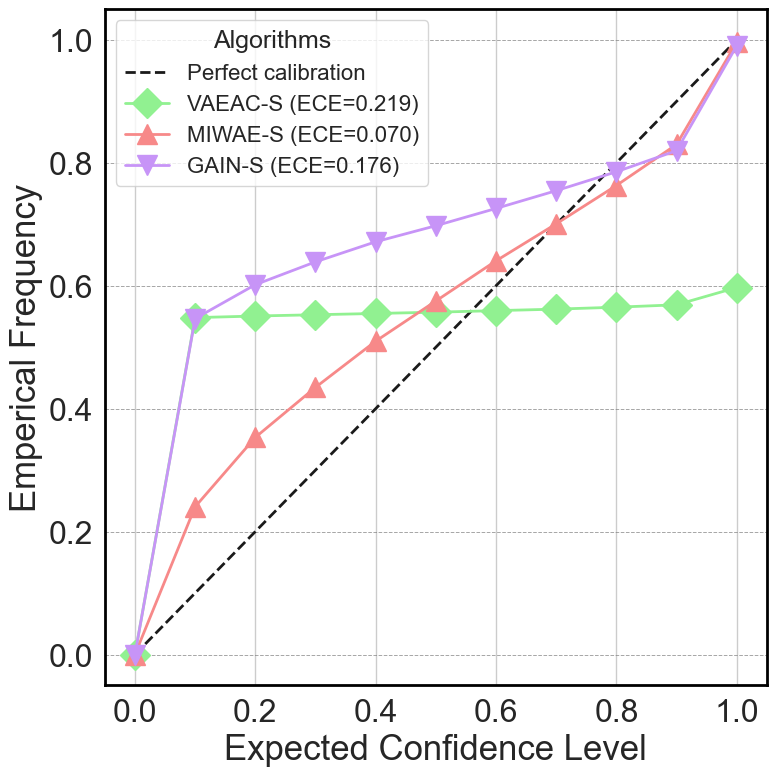

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6  # avoid zero std
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_result = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mcar_results_sample_runs.csv"
)

target_missing_rate = 20
df_filtered = df_result[df_result['MissingRate'] == target_missing_rate]

# Rename algorithms for consistency
df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({
    "OT": "OT-Impute",
    "VAEAC": "VAEAC-S",
    "MIWAE":"MIWAE-S",
    "GAIN":"GAIN-S"
})

algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]
    true_vals = df_algo['TrueValue'].astype(float).values
    mean_vals = df_algo['ImputedMean'].astype(float).values
    std_vals  = df_algo['ImputedStd'].astype(float).values

 

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})"
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Algorithms", fontsize=16, title_fontsize=18)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MCAR20_SampleRuns_Calibration.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


Sample run ECE VS Missing Rate

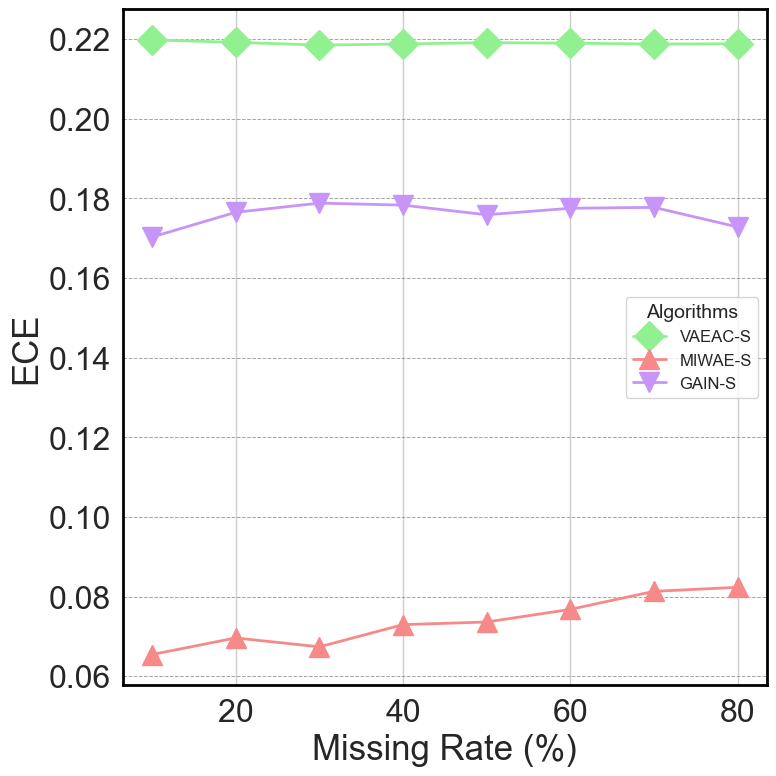

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mcar_results_sample_runs.csv"
)

# Rename algorithms for consistency
df_results['Algorithm'] = df_results['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble": "Ensemble",
    "MIWAE":"MIWAE-S",
    "GAIN":"GAIN-S",
    "VAEAC":"VAEAC-S"
})

algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(title="Algorithms", fontsize=12, title_fontsize=14)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MCAR_SampleRuns_ECE_AllAlgorithms.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MCAR

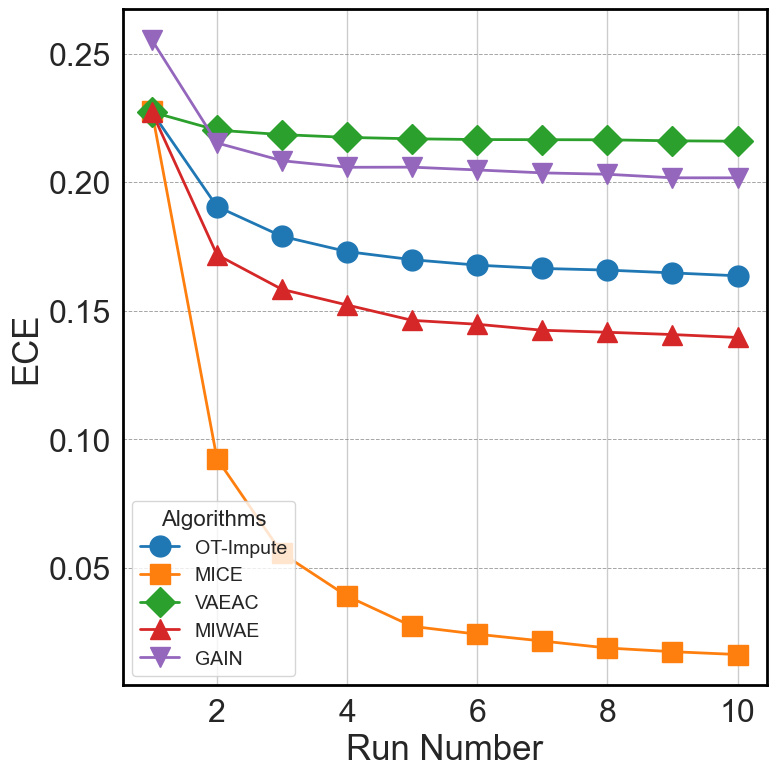

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mcar_results_progressive.csv"
)

df['Algorithm'] = df['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble": "Ensemble",
   
})

missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Run Number", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
plt.legend(title="Algorithms", fontsize=14, title_fontsize=16)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MCAR30_Progressive_ECE_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MCAR ECE VS Sample 

C:\Users\zhossai3\AppData\Local\Temp\ipykernel_552\909011509.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({


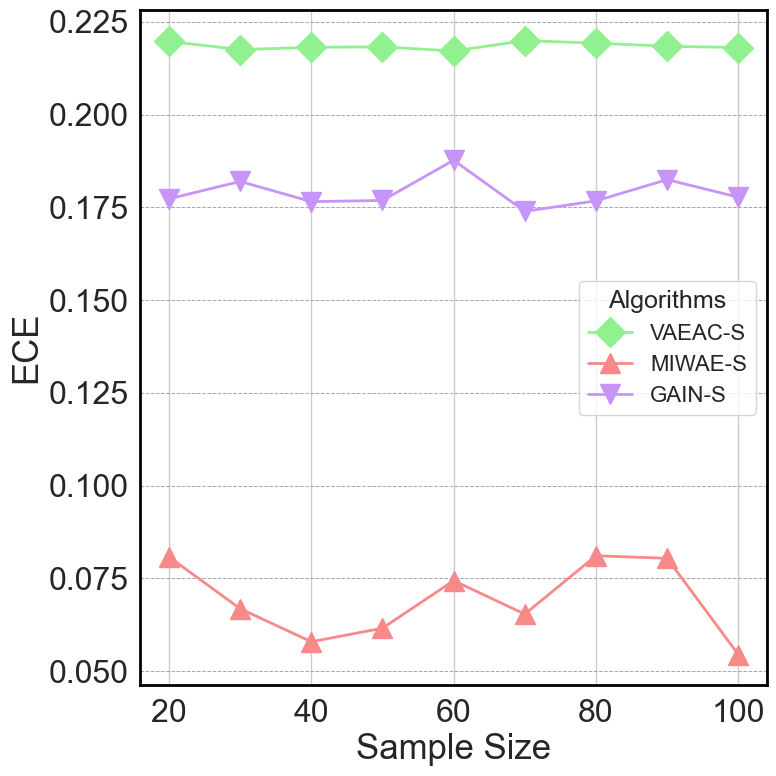

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mcar_results_sample_runs.csv"
)

missing_rate_to_plot = 30
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# Rename algorithms for consistency
df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble": "Ensemble",
    "MIWAE":"MIWAE-S",
    "GAIN":"GAIN-S",
    "VAEAC":"VAEAC-S"
})

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# Compute ECE per sample size
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for sample in sorted(df_filtered["Sample"].unique()):
        sample_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Sample"] == sample)]
        
        true_vals = sample_df['TrueValue'].values
        mean_vals = sample_df['ImputedMean'].values
        std_vals = sample_df['ImputedStd'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Sample": sample,
            "ECE": ece
        })

ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Sample ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Sample"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Sample Size", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Sample Size for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
plt.legend(title="Algorithms", fontsize=16, title_fontsize=18)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MCAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


## MAR

20% MAR calibration curves

C:\Users\zhossai3\AppData\Local\Temp\ipykernel_552\4109588796.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({


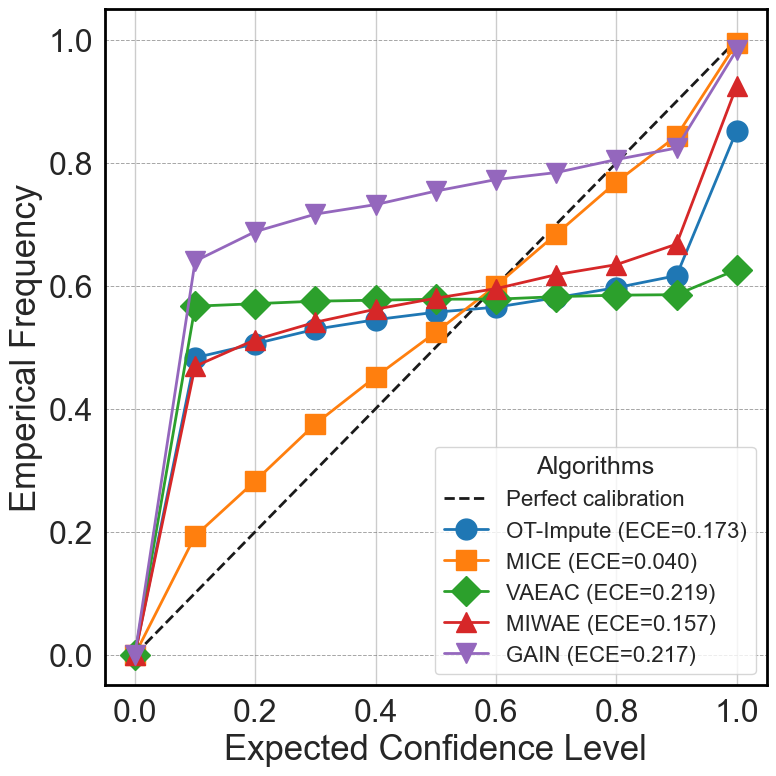

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mar_results_multiple_runs.csv"
)

target_missing_rate = 20  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

# Rename algorithms for consistency
df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble":"Ensemble"
})

algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})"
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Algorithms", fontsize=16, title_fontsize=18)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MAR20_Calibration_multiple_runs.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


Multiple runs ECE VS Missing Rate

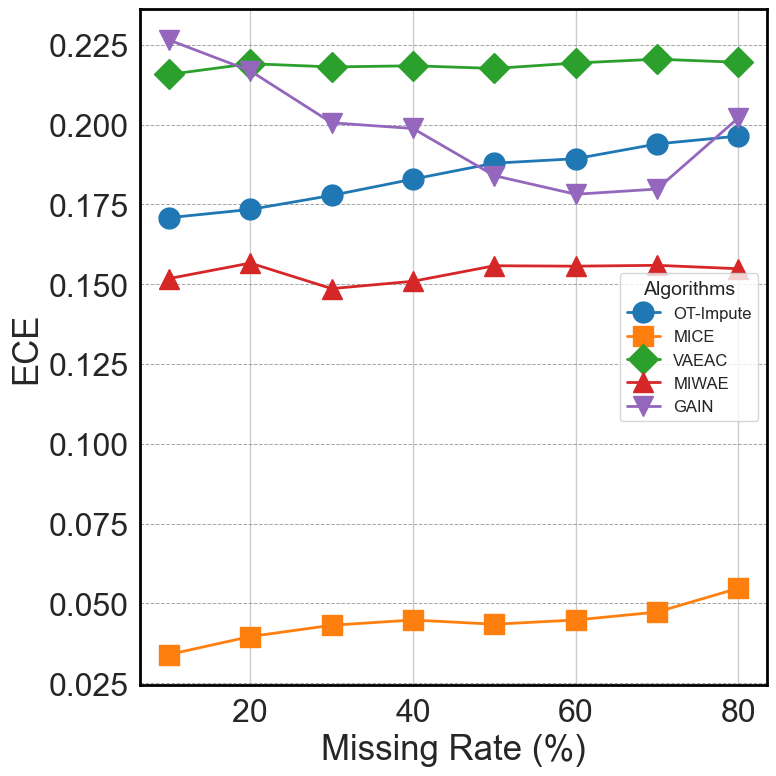

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mar_results_multiple_runs.csv"
)

# Rename algorithms for consistency
df_results['Algorithm'] = df_results['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble": "Ensemble"
})

algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(title="Algorithms", fontsize=12, title_fontsize=14)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MAR_ECE_AllAlgorithms.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


20% MAR Sample runs

C:\Users\zhossai3\AppData\Local\Temp\ipykernel_552\3886682867.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({


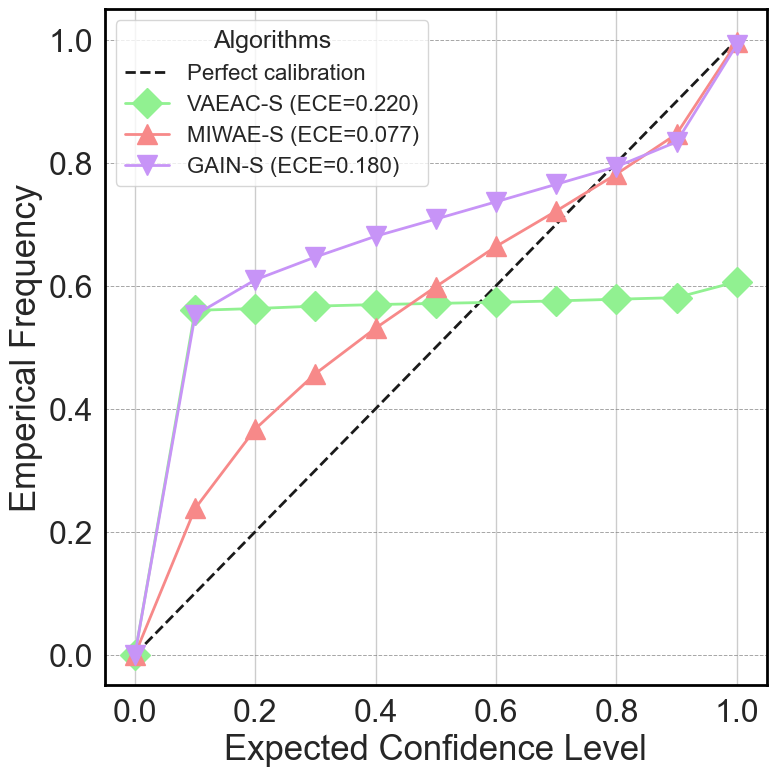

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6  # avoid zero std
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_result = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mar_results_sample_runs.csv"
)

target_missing_rate = 20
df_filtered = df_result[df_result['MissingRate'] == target_missing_rate]

# Rename algorithms for consistency
df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({
    "OT": "OT-Impute",
    "VAEAC": "VAEAC-S",
    "MIWAE":"MIWAE-S",
    "GAIN":"GAIN-S"
})

algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]
    true_vals = df_algo['TrueValue'].astype(float).values
    mean_vals = df_algo['ImputedMean'].astype(float).values
    std_vals  = df_algo['ImputedStd'].astype(float).values

 

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})"
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Algorithms", fontsize=16, title_fontsize=18)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MAR20_SampleRuns_Calibration.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


Sample run ECE VS Missing Rate

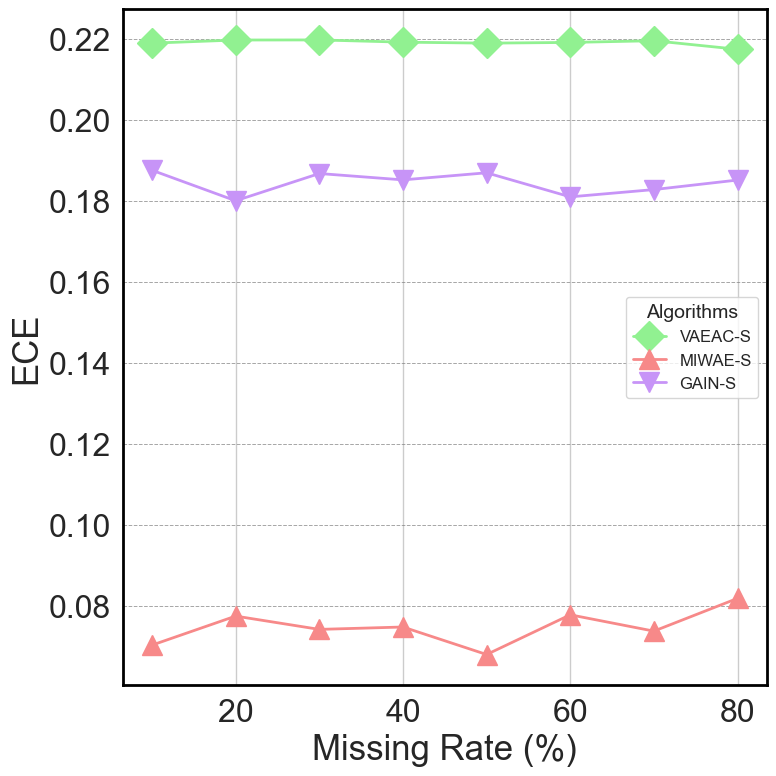

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mar_results_sample_runs.csv"
)

# Rename algorithms for consistency
df_results['Algorithm'] = df_results['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble": "Ensemble",
    "MIWAE":"MIWAE-S",
    "GAIN":"GAIN-S",
    "VAEAC":"VAEAC-S"
})

algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(title="Algorithms", fontsize=12, title_fontsize=14)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MAR_SampleRuns_ECE_AllAlgorithms.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MAR

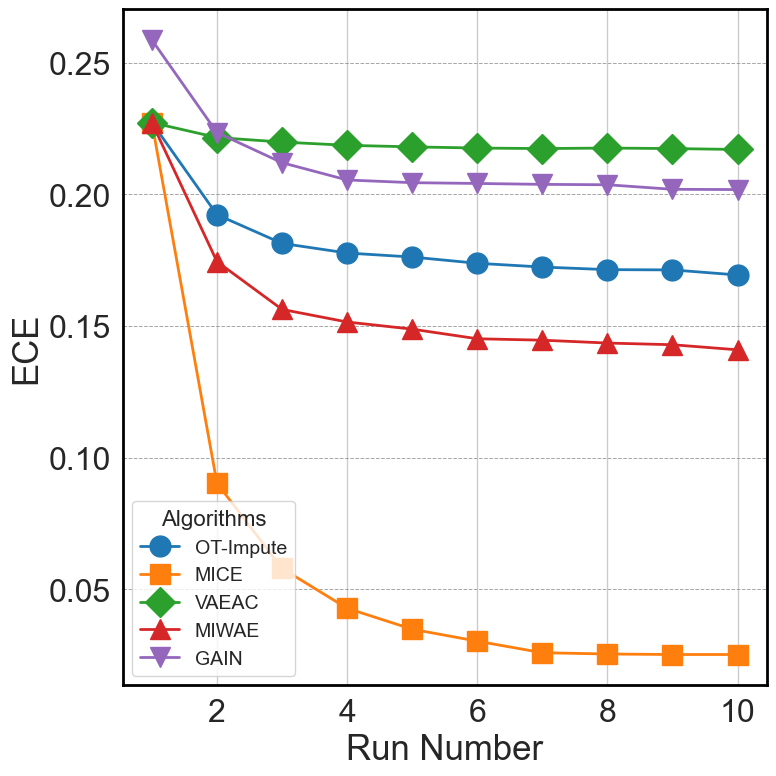

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mar_results_progressive.csv"
)

df['Algorithm'] = df['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble": "Ensemble",
   
})

missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Run Number", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
plt.legend(title="Algorithms", fontsize=14, title_fontsize=16)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MAR30_Progressive_ECE_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MAR ECE VS Sample 

C:\Users\zhossai3\AppData\Local\Temp\ipykernel_552\2081739232.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({


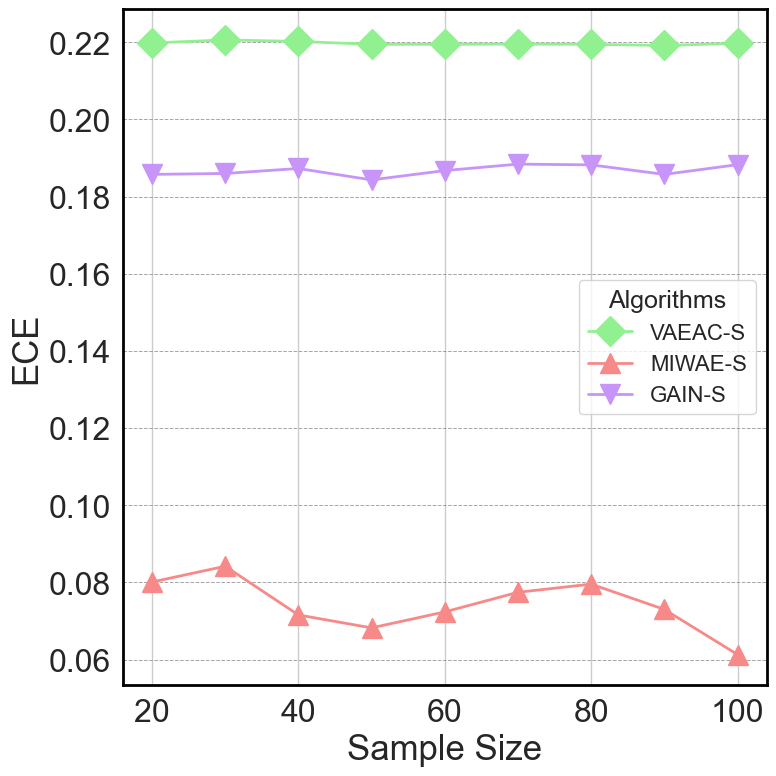

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mar_results_sample_runs.csv"
)

missing_rate_to_plot = 30
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# Rename algorithms for consistency
df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble": "Ensemble",
    "MIWAE":"MIWAE-S",
    "GAIN":"GAIN-S",
    "VAEAC":"VAEAC-S"
})

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# Compute ECE per sample size
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for sample in sorted(df_filtered["Sample"].unique()):
        sample_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Sample"] == sample)]
        
        true_vals = sample_df['TrueValue'].values
        mean_vals = sample_df['ImputedMean'].values
        std_vals = sample_df['ImputedStd'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Sample": sample,
            "ECE": ece
        })

ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Sample ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Sample"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Sample Size", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Sample Size for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
plt.legend(title="Algorithms", fontsize=16, title_fontsize=18)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


## MNAR

20% MNAR calibration curves

C:\Users\zhossai3\AppData\Local\Temp\ipykernel_552\392660229.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({


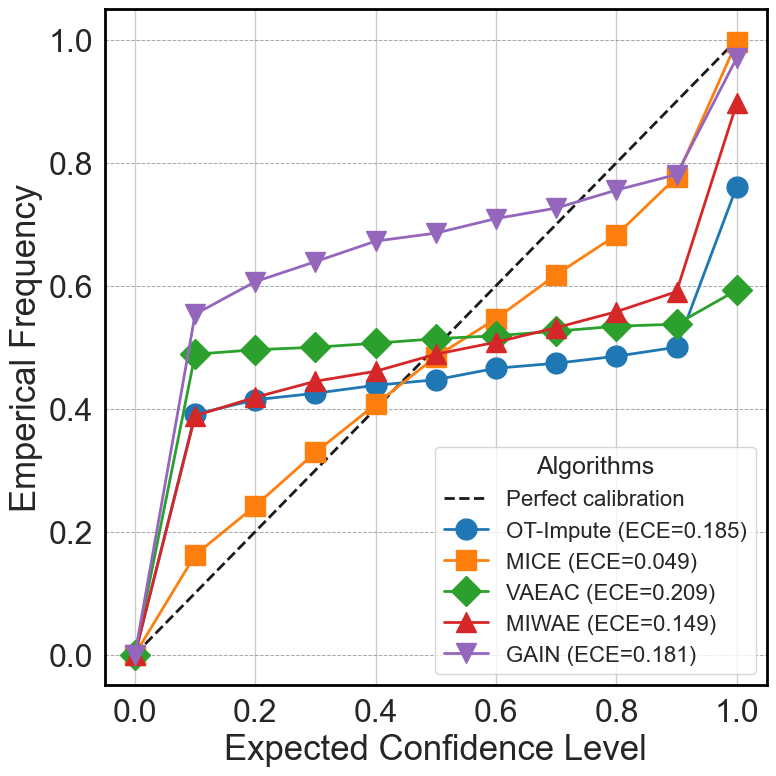

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mnar_results_multiple_runs.csv"
)

target_missing_rate = 20  # example: 20%
df_filtered = df_results[df_results['MissingRate'] == target_missing_rate]

# Rename algorithms for consistency
df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble":"Ensemble"
})

algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]

    true_vals = df_algo['TrueValue'].values
    mean_vals = df_algo['ImputedMean'].values
    std_vals = df_algo['ImputedStd'].values

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})  # fallback
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})"
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)  # changed from Empirical Frequency

# Legend (smaller, clean)
plt.legend(title="Algorithms", fontsize=16, title_fontsize=18)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MNAR20_Calibration_multiple runs.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


Multiple runs ECE VS Missing Rate

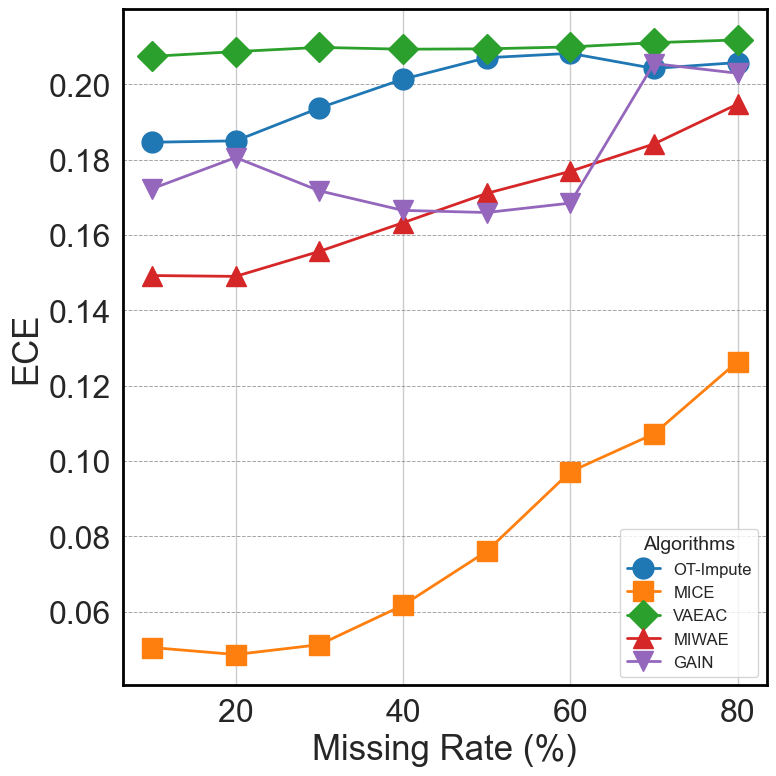

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mnar_results_multiple_runs.csv"
)

# Rename algorithms for consistency
df_results['Algorithm'] = df_results['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble": "Ensemble"
})

algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(title="Algorithms", fontsize=12, title_fontsize=14)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MNAR_ECE_AllAlgorithms.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


20% MCAR Sample runs

C:\Users\zhossai3\AppData\Local\Temp\ipykernel_552\2296299506.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({


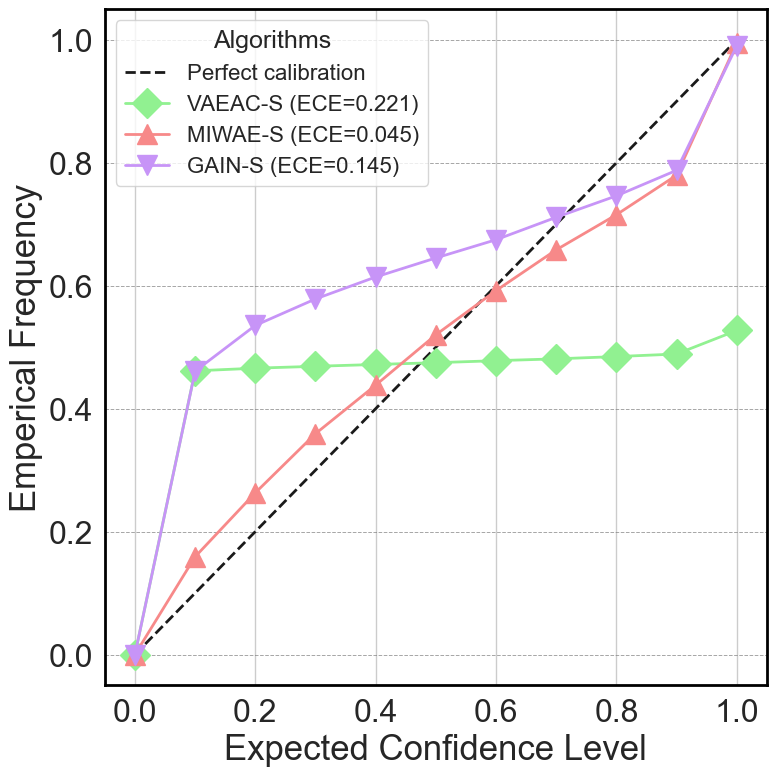

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6  # avoid zero std
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df_result = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mnar_results_sample_runs.csv"
)

target_missing_rate = 20
df_filtered = df_result[df_result['MissingRate'] == target_missing_rate]

# Rename algorithms for consistency
df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({
    "OT": "OT-Impute",
    "VAEAC": "VAEAC-S",
    "MIWAE":"MIWAE-S",
    "GAIN":"GAIN-S"
})

algorithms = df_filtered['Algorithm'].unique()

# ---- Consistent Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# ---- Plot ----
plt.figure(figsize=(8, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)

for algo in algorithms:
    df_algo = df_filtered[df_filtered['Algorithm'] == algo]
    true_vals = df_algo['TrueValue'].astype(float).values
    mean_vals = df_algo['ImputedMean'].astype(float).values
    std_vals  = df_algo['ImputedStd'].astype(float).values

 

    quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
    ece = np.abs(np.array(proportions) - quantiles).mean()

    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        quantiles, proportions,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=f"{algo} (ECE={ece:.3f})"
    )

# Axis labels
plt.xlabel("Expected Confidence Level", fontsize=x_label_fontsize)
plt.ylabel("Emperical Frequency", fontsize=y_label_fontsize)

# Legend
plt.legend(title="Algorithms", fontsize=16, title_fontsize=18)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MNAR20_SampleRuns_Calibration.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


Sample run ECE VS Missing Rate

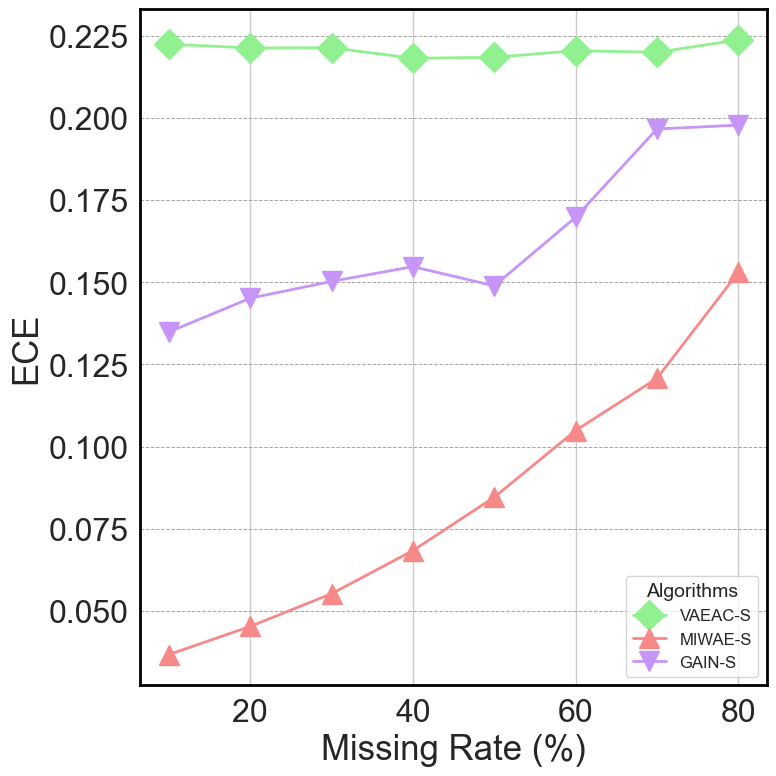

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def compute_ece(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    
    ece = np.abs(np.array(proportions) - quantiles).mean()
    return ece

# Load CSV results
df_results = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mnar_results_sample_runs.csv"
)

# Rename algorithms for consistency
df_results['Algorithm'] = df_results['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble": "Ensemble",
    "MIWAE":"MIWAE-S",
    "GAIN":"GAIN-S",
    "VAEAC":"VAEAC-S"
})

algorithms = df_results['Algorithm'].unique()

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# ---- Plot ECE vs Missing Rate for all algorithms ----
plt.figure(figsize=(8, 8))

for algo in algorithms:
    df_algo = df_results[df_results['Algorithm'] == algo]
    missing_rates = sorted(df_algo['MissingRate'].unique())
    ece_values = []
    
    for mr in missing_rates:
        df_mr = df_algo[df_algo['MissingRate'] == mr]
        true_vals = df_mr['TrueValue'].values
        mean_vals = df_mr['ImputedMean'].values
        std_vals = df_mr['ImputedStd'].values
        ece = compute_ece(true_vals, mean_vals, std_vals)
        ece_values.append(ece)
    
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        missing_rates, ece_values,
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Missing Rate (%)", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title("ECE vs Missing Rate for All Algorithms", fontsize=28)

# Legend
plt.legend(title="Algorithms", fontsize=12, title_fontsize=14)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MNAR_SampleRuns_ECE_AllAlgorithms.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


ECE VS Run Number 30% MNAR

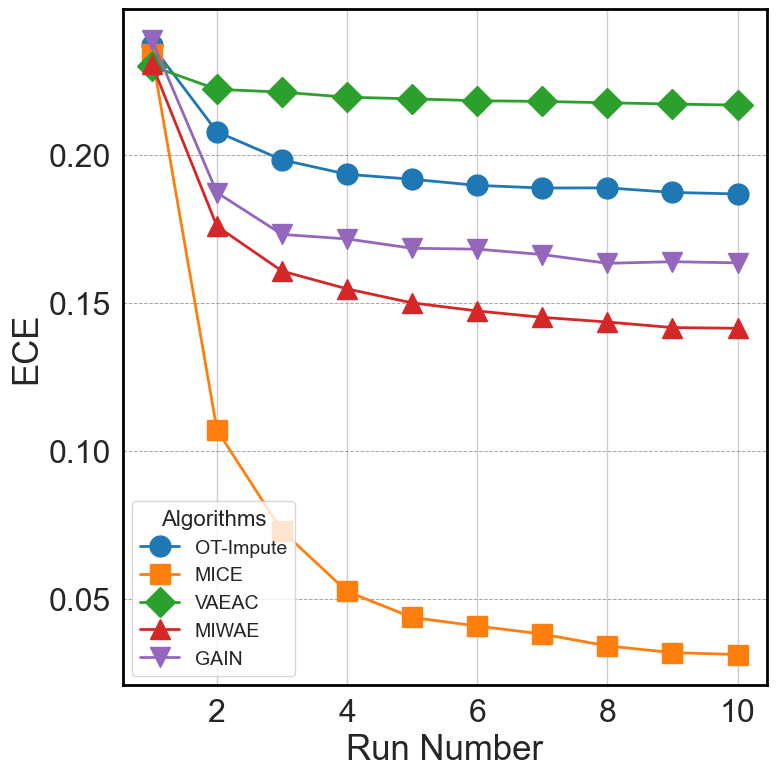

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mnar_results_progressive.csv"
)

df['Algorithm'] = df['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble": "Ensemble",
   
})

missing_rate_to_plot = 30  # example

# Filter for chosen missing rate
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]



# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15


plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# Compute ECE per run
ece_results = []

for algo in df_filtered["Algorithm"].unique():
    for run in sorted(df_filtered["Run"].unique()):
        run_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Run"] == run)]
        
        true_vals = run_df['TrueValue'].values
        mean_vals = run_df['MeanSoFar'].values
        std_vals = run_df['StdSoFar'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Run": run,
            "ECE": ece
        })

# Convert to DataFrame
ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Run ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Run"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Run Number", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Run for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
plt.legend(title="Algorithms", fontsize=14, title_fontsize=16)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MNAR30_Progressive_ECE_Run.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()


30% MNAR ECE VS Sample 

C:\Users\zhossai3\AppData\Local\Temp\ipykernel_552\394397747.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({


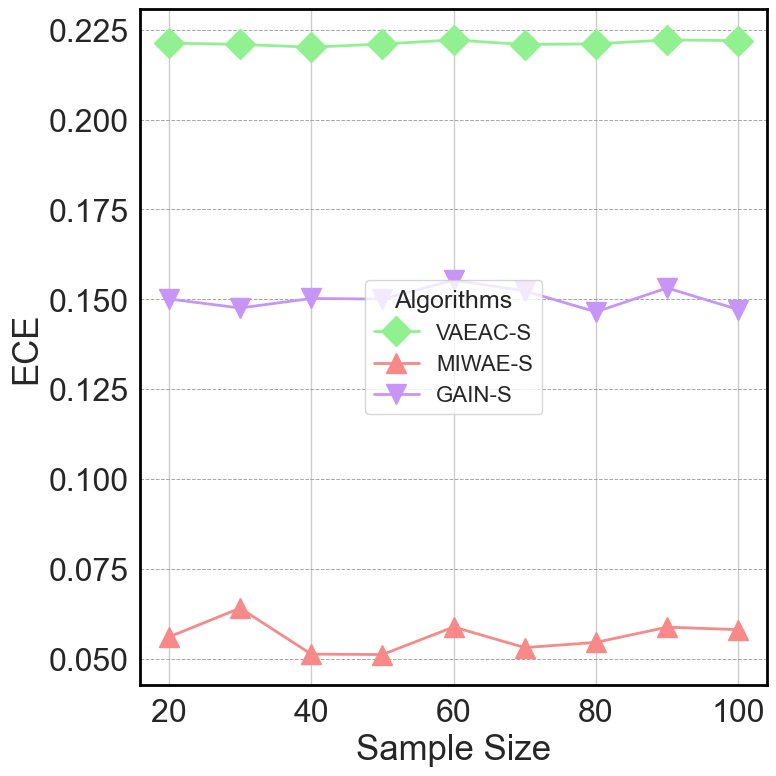

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

def calibration_curve_points(true_values, imputed_mean, imputed_std):
    imputed_std_safe = imputed_std + 1e-6
    cdf_vals = norm.cdf(true_values, loc=imputed_mean, scale=imputed_std_safe)
    quantiles = np.linspace(0, 1, 11)
    proportions = [(cdf_vals < q).mean() for q in quantiles]
    return quantiles, proportions

# Load CSV results
df = pd.read_csv(
    r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\results\Disease_mnar_results_sample_runs.csv"
)

missing_rate_to_plot = 30
df_filtered = df[df["MissingRate"] == missing_rate_to_plot]

# Rename algorithms for consistency
df_filtered['Algorithm'] = df_filtered['Algorithm'].replace({
    "OT": "OT-Impute",
    "Ensamble": "Ensemble",
    "MIWAE":"MIWAE-S",
    "GAIN":"GAIN-S",
    "VAEAC":"VAEAC-S"
})

# ---- Plot Styling ----
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 20
legend_label_fontsize = 18
marker_size = 15

plt.rcParams.update({
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

sns.set(style="whitegrid", font_scale=1.2)

# Define consistent colors and markers
algo_styles = {
    "OT-Impute":   {"color": "#1f77b4", "marker": "o"},   # Blue circle
    "MICE":        {"color": "#ff7f0e", "marker": "s"},   # Orange square
    "VAEAC":         {"color": "#2ca02c", "marker": "D"},   # Green diamond
    "MIWAE":       {"color": "#d62728", "marker": "^"},   # Red triangle-up
    "GAIN":        {"color": "#9467bd", "marker": "v"},   # Purple triangle-down
    "Ensemble":    {"color": "#e00eb2", "marker": "P"},   # Brown plus

    "VAEAC-S": {"color": "#91f191", "marker": "D"},
    "MIWAE-S": {"color": "#f78989", "marker": "^"},
    "GAIN-S": {"color": "#c794f7", "marker": "v"},
}

# Compute ECE per sample size
ece_results = []
for algo in df_filtered["Algorithm"].unique():
    for sample in sorted(df_filtered["Sample"].unique()):
        sample_df = df_filtered[(df_filtered["Algorithm"] == algo) & (df_filtered["Sample"] == sample)]
        
        true_vals = sample_df['TrueValue'].values
        mean_vals = sample_df['ImputedMean'].values
        std_vals = sample_df['ImputedStd'].values
    
        quantiles, proportions = calibration_curve_points(true_vals, mean_vals, std_vals)
        ece = np.abs(np.array(proportions) - quantiles).mean()
        
        ece_results.append({
            "Algorithm": algo,
            "Sample": sample,
            "ECE": ece
        })

ece_df = pd.DataFrame(ece_results)

# ---- Plot ECE vs Sample ----
plt.figure(figsize=(8, 8))

for algo in ece_df["Algorithm"].unique():
    algo_data = ece_df[ece_df["Algorithm"] == algo]
    style = algo_styles.get(algo, {"color": "black", "marker": "o"})
    plt.plot(
        algo_data["Sample"], algo_data["ECE"],
        marker=style["marker"], color=style["color"],
        markersize=marker_size, linewidth=2,
        label=algo
    )

# Axis labels and title
plt.xlabel("Sample Size", fontsize=x_label_fontsize)
plt.ylabel("ECE", fontsize=y_label_fontsize)
#plt.title(f"ECE vs Sample Size for {missing_rate_to_plot}% Missingness", fontsize=28)

# Legend
plt.legend(title="Algorithms", fontsize=16, title_fontsize=18)

# Borders (black edges)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Grid lines
ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Tick params
ax.tick_params(axis='x', labelsize=x_tick_fontsize)
ax.tick_params(axis='y', labelsize=y_tick_fontsize)
ax.yaxis.set_tick_params(width=1.5, length=5)

plt.tight_layout()

# Save
save_path = r"C:\Users\zhossai3\Desktop\Uncertainty\imputation_Uncertainty\Output\Disease_MNAR30_ECE_vs_Sample.pdf"
plt.savefig(save_path, format="pdf", bbox_inches="tight")

plt.show()
